In [4]:
# Cell 1: Initialize iterator and load JSONL data
import json
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from typing import Dict, List

def parse_bbox_data(bbox_str: str) -> Dict:
    """Parse the JSON string containing bbox and explanation data."""
    try:
        # Extract JSON from the string (remove ```json and ```)
        json_str = bbox_str.strip()
        if json_str.startswith('```json'):
            json_str = json_str[7:]
        if json_str.endswith('```'):
            json_str = json_str[:-3]
        
        return json.loads(json_str.strip())
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

def load_jsonl(file_path: str) -> List[Dict]:
    """Load JSONL file and return list of samples."""
    samples = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                samples.append(json.loads(line.strip()))
    return samples

def calculate_iou(bbox1: List[int], bbox2: List[int]) -> float:
    """Calculate Intersection over Union (IoU) between two bounding boxes."""
    
    x1_1, y1_1, x2_1, y2_1 = bbox1
    x1_2, y1_2, x2_2, y2_2 = bbox2
    
    # Calculate intersection coordinates
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)
    
    # Calculate intersection area
    if x2_i <= x1_i or y2_i <= y1_i:
        intersection_area = 0
    else:
        intersection_area = (x2_i - x1_i) * (y2_i - y1_i)
    
    # Calculate union area
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = area1 + area2 - intersection_area
    
    # Calculate IoU
    if union_area == 0:
        return 0
    return intersection_area / union_area

# Load the JSONL data
base_dir = "/home/jovyan/image-artifacts/src/train/LLaMA-Factory"
jsonl_path = "/home/jovyan/image-artifacts/src/train/LLaMA-Factory/qwen_finetuned_predictions_eval.jsonl"
samples = load_jsonl(jsonl_path)

# Create iterator over samples
sample_iter = iter(samples)
current_index = 0

print(f"✅ Loaded {len(samples)} samples from {jsonl_path}")
print("🔄 Ready to visualize! Run the next cell to see the first sample.")
print("💡 Re-run the next cell to advance to subsequent samples.")


✅ Loaded 73 samples from /home/jovyan/image-artifacts/src/train/LLaMA-Factory/qwen_finetuned_predictions_eval.jsonl
🔄 Ready to visualize! Run the next cell to see the first sample.
💡 Re-run the next cell to advance to subsequent samples.


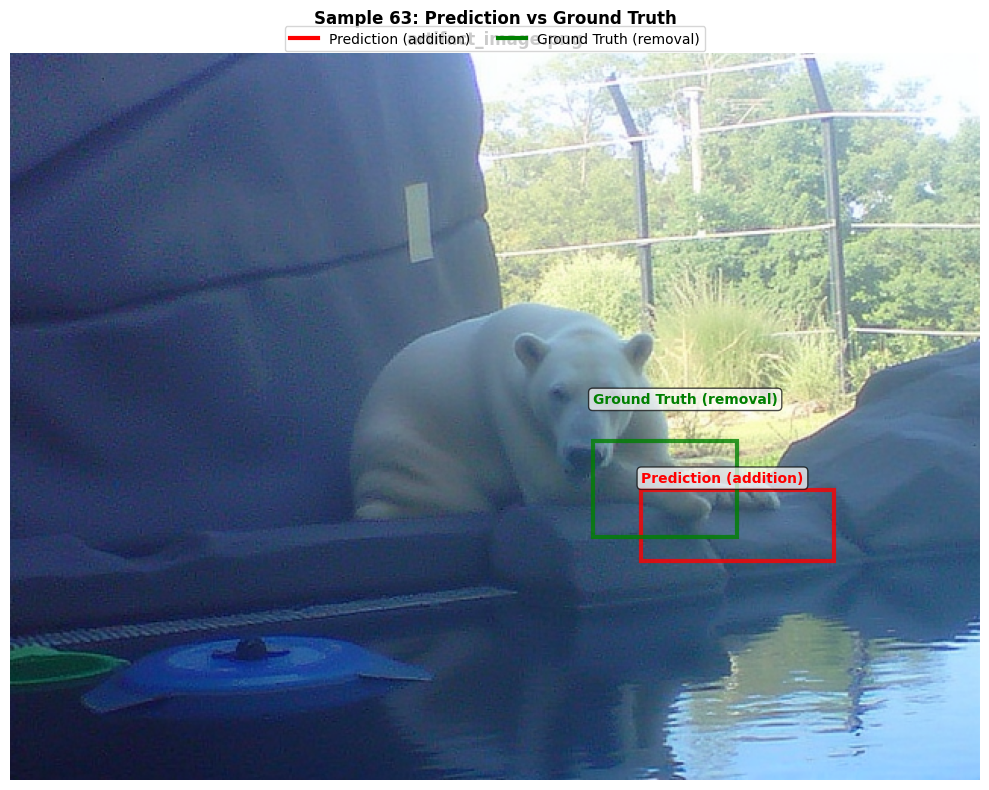

📁 Image: /home/jovyan/image-artifacts/src/train/LLaMA-Factory/data/artifacts/removal/filtered_image_212803/artifact_image.png
📊 Sample 63 of 73

🔴 PREDICTION:
   Explanation: In the highlighted region, the bear's paw appears to have an unnatural duplication or extension. There seems to be an extra paw or part of a paw that is not aligned with the rest of the bear's body, creating an unusual and anatomically incorrect appearance.
   Bbox: [416, 288, 543, 335]
   Artifact: addition

🟢 GROUND TRUTH:
   Explanation: In the highlighted region, the polar bear's paw appears to have an unnatural smoothness and lacks the typical definition and texture expected. The area seems to be missing the usual contours and details, such as the visible separation of toes or the natural fur texture, making it look artificially altered or incomplete.
   Bbox: [384, 256, 479, 319]
   Artifact: removal

📏 IoU (Intersection over Union): 0.195
   ❌ Poor overlap

💡 Re-run this cell to see the next sample


In [61]:
try:
    # Get next sample
    sample = next(sample_iter)
    current_index += 1

    # Parse prediction and label data
    label_data = parse_bbox_data(sample['label'])[0]
    predict_data = parse_bbox_data(sample['predict'])[0]

    # Get image path
    image_paths = sample['image']
    if isinstance(image_paths, list):
        image_path = image_paths[0]
    else:
        image_path = image_paths

    image_path = os.path.join(base_dir, image_path)

    # Load image
    if os.path.exists(image_path):
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Create figure with one subplot
        fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

        # Plot: Original image with both bboxes
        ax1.imshow(image_rgb)
        ax1.set_title(f'Sample {current_index}: Prediction vs Ground Truth\n{os.path.basename(image_path)}', 
                      fontsize=12, fontweight='bold')
        pred_type = predict_data['artifact_type']
        label_type = label_data['artifact_type']
        # Draw prediction bbox (red)
        if 'bbox_2d' in predict_data:
            x1, y1, x2, y2 = predict_data['bbox_2d']
            width, height = x2 - x1, y2 - y1
            rect_pred = patches.Rectangle((x1, y1), width, height, linewidth=3, 
                                          edgecolor='red', facecolor='none', alpha=0.8)
            ax1.add_patch(rect_pred)
            ax1.text(x1, y1 - 5, f'Prediction ({pred_type})', color='red', fontsize=10, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

        # Draw label bbox (green)
        if 'bbox_2d' in label_data:
            x1, y1, x2, y2 = label_data['bbox_2d']
            width, height = x2 - x1, y2 - y1
            rect_label = patches.Rectangle((x1, y1), width, height, linewidth=3, 
                                           edgecolor='green', facecolor='none', alpha=0.8)
            ax1.add_patch(rect_label)
            ax1.text(x1, y1 - 25, f'Ground Truth ({label_type})', color='green', fontsize=10, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

        ax1.axis('off')

        # Add legend
        from matplotlib.lines import Line2D
# Extract artifact types (default to 'N/A' if missing)
        legend_elements = [
            Line2D([0], [0], color='red', lw=3, label=f'Prediction ({pred_type})'),
            Line2D([0], [0], color='green', lw=3, label=f'Ground Truth ({label_type})')
        ]
        fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2)

        plt.tight_layout()
        plt.show()

        # Print detailed information
        print(f"📁 Image: {image_path}")
        print(f"📊 Sample {current_index} of {len(samples)}")
        print(f"\n{'='*80}")

        print(f"🔴 PREDICTION:")
        print(f"   Explanation: {predict_data.get('explanation', 'N/A')}")
        print(f"   Bbox: {predict_data.get('bbox_2d', 'N/A')}")
        print(f"   Artifact: {predict_data.get('artifact_type', 'N/A')}")

        print(f"\n🟢 GROUND TRUTH:")
        print(f"   Explanation: {label_data.get('explanation', 'N/A')}")
        print(f"   Bbox: {label_data.get('bbox_2d', 'N/A')}")
        print(f"   Artifact: {label_data.get('artifact_type', 'N/A')}")

        # Calculate and print IoU
        if 'bbox_2d' in predict_data and 'bbox_2d' in label_data:
            iou = calculate_iou(predict_data['bbox_2d'], label_data['bbox_2d'])
            print(f"\n📏 IoU (Intersection over Union): {iou:.3f}")

            # IoU interpretation
            if iou > 0.7:
                print("   ✅ Excellent overlap!")
            elif iou > 0.5:
                print("   👍 Good overlap")
            elif iou > 0.3:
                print("   ⚠️  Moderate overlap")
            else:
                print("   ❌ Poor overlap")

        print(f"\n{'='*80}")
        print(f"💡 Re-run this cell to see the next sample")

    else:
        print(f"❌ Image not found: {image_path}")
        print("⏭️  Re-run to try next sample")

except StopIteration:
    print("🎉 Reached the end of all samples!")
    print("🔄 Run the first cell again to restart from the beginning.")

In [6]:
# Cell 3: Jump to specific sample (optional - change the index and run)
jump_to_index = 10  # Change this number to jump to a specific sample

if 0 <= jump_to_index < len(samples):
    # Reset iterator to specific position
    sample_iter = iter(samples[jump_to_index:])
    current_index = jump_to_index - 1  # Will be incremented in next cell
    print(f"✅ Ready to show sample {jump_to_index}")
    print("🚀 Run the visualization cell (Cell 2) to see this sample")
else:
    print(f"❌ Invalid index. Please choose between 0 and {len(samples)-1}")


✅ Ready to show sample 10
🚀 Run the visualization cell (Cell 2) to see this sample


📊 Calculating statistics across all samples...
------------------------------------------------------------
📈 DATASET STATISTICS
Total samples: 73
Missing images: 0
Samples with IoU: 73
Samples with artifact type pairs: 73

🎯 ARTIFACT TYPE CLASSIFICATION ACCURACY:
   Correct predictions: 53
   Total predictions: 73
   Accuracy: 0.726 (72.6%)

📊 PER-CLASS ACCURACY:
   addition: 26/34 (0.765)
   distortion: 4/8 (0.500)
   removal: 23/31 (0.742)

📏 IoU STATISTICS:
   Mean IoU: 0.340
   Median IoU: 0.269
   Min IoU: 0.000
   Max IoU: 1.000
   Std IoU: 0.295

📊 IoU DISTRIBUTION:
   Excellent (>0.7): 10 (13.7%)
   Good (0.5-0.7): 14 (19.2%)
   Moderate (0.3-0.5): 12 (16.4%)
   Poor (≤0.3): 37 (50.7%)

🎯 ARTIFACT TYPES (PREDICTIONS):
   addition: 33
   removal: 32
   distortion: 8

🎯 ARTIFACT TYPES (GROUND TRUTH):
   addition: 34
   removal: 31
   distortion: 8


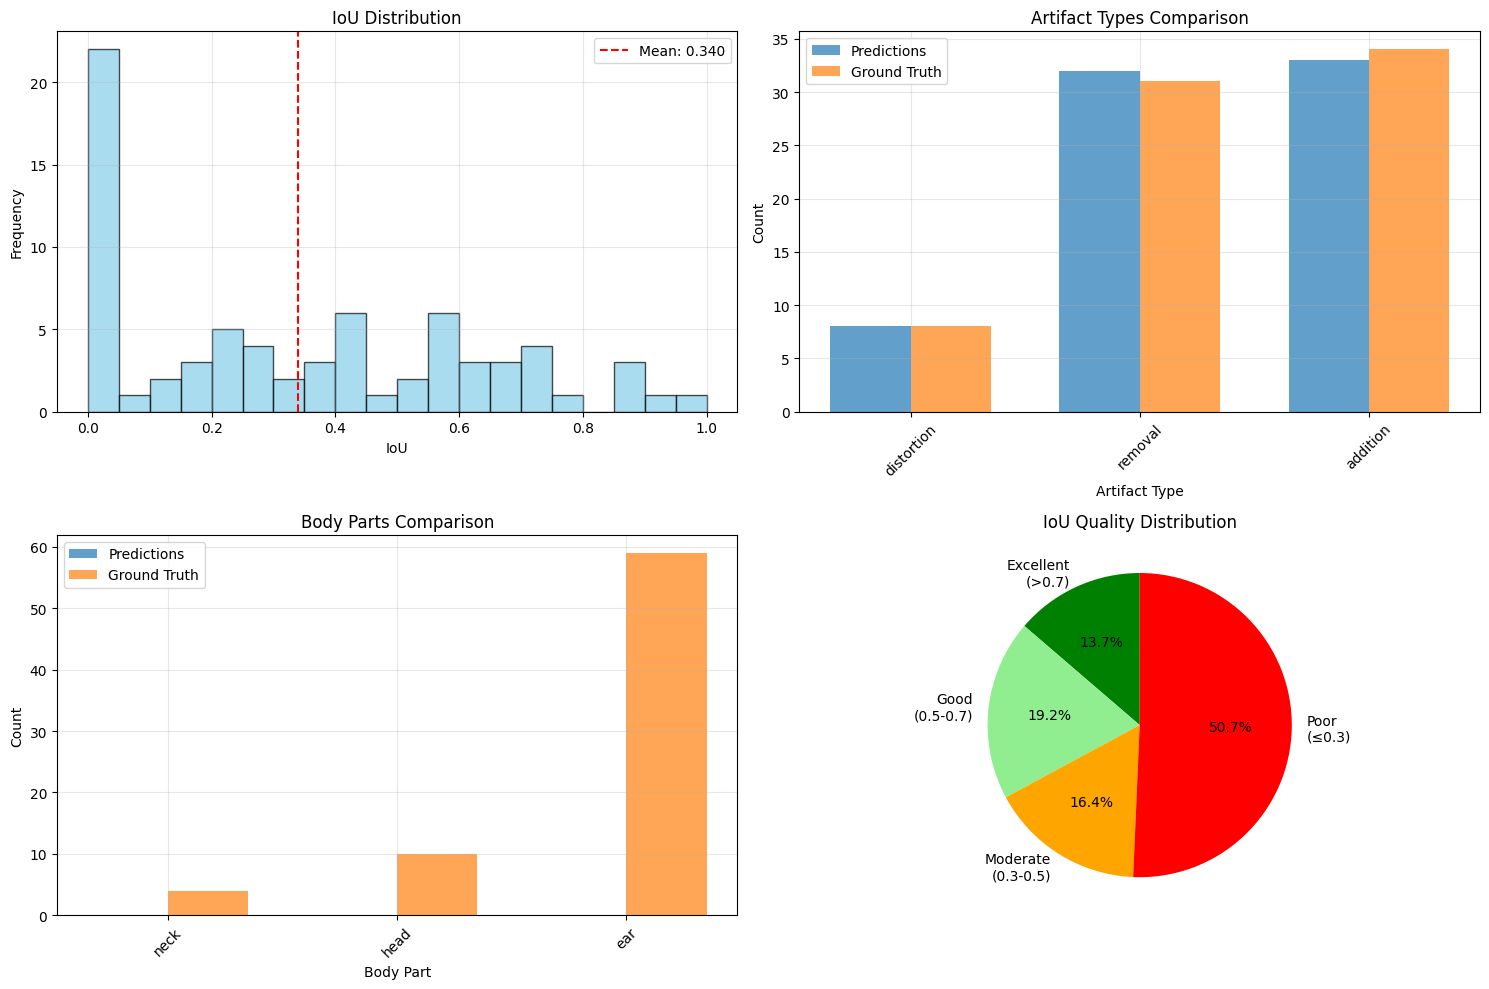


✅ Statistics complete!


In [7]:
# Cell 4: Calculate statistics across all samples
import re
from collections import defaultdict

def extract_artifact_type(explanation):
    """Extract artifact type from explanation text."""
    # Look for patterns like "artifact of type X"
    match = re.search(r'artifact of type (\w+)', explanation.lower())
    if match:
        return match.group(1)
    return "unknown"

def extract_body_part(explanation):
    """Extract body part from explanation text."""
    # Common body parts in the explanations
    body_parts = ['head', 'neck', 'ear', 'leg', 'tail', 'body', 'face', 'eye', 'nose', 'mouth']
    explanation_lower = explanation.lower()
    for part in body_parts:
        if part in explanation_lower:
            return part
    return "other"

# Calculate statistics
ious = []
artifact_types_pred = defaultdict(int)
artifact_types_label = defaultdict(int)
body_parts_pred = defaultdict(int)
body_parts_label = defaultdict(int)
missing_images = 0

# For classification accuracy calculation
artifact_type_pairs = []  # Store (predicted, ground_truth) pairs

print("📊 Calculating statistics across all samples...")
print("-" * 60)

for i, sample in enumerate(samples):
    # Parse data    predict_data = parse_bbox_data(sample['predict'])[0]
    # label_data = parse_bbox_data(sample['label'])[0]
    try:
        predict_data = parse_bbox_data(sample['predict'])[0]
        label_data = parse_bbox_data(sample['label'])[0]
        
        # Check if image exists
        image_path = sample['image'][0] if isinstance(sample['image'], list) else sample['image']
        if not os.path.exists(image_path):
            missing_images += 1
        
        # Calculate IoU
        if 'bbox_2d' in predict_data and 'bbox_2d' in label_data:
            iou = calculate_iou(predict_data['bbox_2d'], label_data['bbox_2d'])
            ious.append(iou)
        
        # Extract artifact types
        pred_artifact_type = None
        label_artifact_type = None
        
        if 'explanation' in predict_data:
            pred_artifact_type = predict_data['artifact_type'].lower()
            # pred_artifact_type = extract_artifact_type(predict_data['explanation'])
            artifact_types_pred[pred_artifact_type] += 1
        
        if 'explanation' in label_data:
            label_artifact_type = label_data['artifact_type']
            # label_artifact_type = extract_artifact_type(label_data['explanation'])
            artifact_types_label[label_artifact_type] += 1
            
            body_part = extract_body_part(label_data['explanation'])
            body_parts_label[body_part] += 1
        
        # Store artifact type pair for accuracy calculation
        if pred_artifact_type is not None and label_artifact_type is not None:
            artifact_type_pairs.append((pred_artifact_type, label_artifact_type))
    except:
        pass

# Print statistics
print(f"📈 DATASET STATISTICS")
print(f"Total samples: {len(samples)}")
print(f"Missing images: {missing_images}")
print(f"Samples with IoU: {len(ious)}")
print(f"Samples with artifact type pairs: {len(artifact_type_pairs)}")

# Calculate artifact type classification accuracy
if artifact_type_pairs:
    correct_predictions = sum(1 for pred, label in artifact_type_pairs if pred == label)
    total_predictions = len(artifact_type_pairs)
    accuracy = correct_predictions / total_predictions
    
    print(f"\n🎯 ARTIFACT TYPE CLASSIFICATION ACCURACY:")
    print(f"   Correct predictions: {correct_predictions}")
    print(f"   Total predictions: {total_predictions}")
    print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
    
    # Calculate per-class accuracy
    from collections import defaultdict
    per_class_correct = defaultdict(int)
    per_class_total = defaultdict(int)
    
    for pred, label in artifact_type_pairs:
        per_class_total[label] += 1
        if pred == label:
            per_class_correct[label] += 1
    
    print(f"\n📊 PER-CLASS ACCURACY:")
    for artifact_type in sorted(per_class_total.keys()):
        class_accuracy = per_class_correct[artifact_type] / per_class_total[artifact_type]
        print(f"   {artifact_type}: {per_class_correct[artifact_type]}/{per_class_total[artifact_type]} ({class_accuracy:.3f})")
else:
    print("\n⚠️  No artifact type pairs found for accuracy calculation")

if ious:
    print(f"\n📏 IoU STATISTICS:")
    print(f"   Mean IoU: {np.mean(ious):.3f}")
    print(f"   Median IoU: {np.median(ious):.3f}")
    print(f"   Min IoU: {np.min(ious):.3f}")
    print(f"   Max IoU: {np.max(ious):.3f}")
    print(f"   Std IoU: {np.std(ious):.3f}")
    
    # IoU ranges
    excellent = sum(1 for iou in ious if iou > 0.7)
    good = sum(1 for iou in ious if 0.5 < iou <= 0.7)
    moderate = sum(1 for iou in ious if 0.3 < iou <= 0.5)
    poor = sum(1 for iou in ious if iou <= 0.3)
    
    print(f"\n📊 IoU DISTRIBUTION:")
    print(f"   Excellent (>0.7): {excellent} ({excellent/len(ious)*100:.1f}%)")
    print(f"   Good (0.5-0.7): {good} ({good/len(ious)*100:.1f}%)")
    print(f"   Moderate (0.3-0.5): {moderate} ({moderate/len(ious)*100:.1f}%)")
    print(f"   Poor (≤0.3): {poor} ({poor/len(ious)*100:.1f}%)")

print(f"\n🎯 ARTIFACT TYPES (PREDICTIONS):")
for artifact_type, count in sorted(artifact_types_pred.items(), key=lambda x: x[1], reverse=True):
    print(f"   {artifact_type}: {count}")

print(f"\n🎯 ARTIFACT TYPES (GROUND TRUTH):")
for artifact_type, count in sorted(artifact_types_label.items(), key=lambda x: x[1], reverse=True):
    print(f"   {artifact_type}: {count}")

# Create plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# IoU histogram
if ious:
    ax1.hist(ious, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(np.mean(ious), color='red', linestyle='--', label=f'Mean: {np.mean(ious):.3f}')
    ax1.set_xlabel('IoU')
    ax1.set_ylabel('Frequency')
    ax1.set_title('IoU Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# Artifact types comparison
artifact_types = list(set(list(artifact_types_pred.keys()) + list(artifact_types_label.keys())))
pred_counts = [artifact_types_pred[t] for t in artifact_types]
label_counts = [artifact_types_label[t] for t in artifact_types]

x = np.arange(len(artifact_types))
width = 0.35

ax2.bar(x - width/2, pred_counts, width, label='Predictions', alpha=0.7)
ax2.bar(x + width/2, label_counts, width, label='Ground Truth', alpha=0.7)
ax2.set_xlabel('Artifact Type')
ax2.set_ylabel('Count')
ax2.set_title('Artifact Types Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(artifact_types, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Body parts comparison
body_parts = list(set(list(body_parts_pred.keys()) + list(body_parts_label.keys())))
pred_counts_body = [body_parts_pred[t] for t in body_parts]
label_counts_body = [body_parts_label[t] for t in body_parts]

x_body = np.arange(len(body_parts))
ax3.bar(x_body - width/2, pred_counts_body, width, label='Predictions', alpha=0.7)
ax3.bar(x_body + width/2, label_counts_body, width, label='Ground Truth', alpha=0.7)
ax3.set_xlabel('Body Part')
ax3.set_ylabel('Count')
ax3.set_title('Body Parts Comparison')
ax3.set_xticks(x_body)
ax3.set_xticklabels(body_parts, rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

# IoU ranges pie chart
if ious:
    labels = ['Excellent\n(>0.7)', 'Good\n(0.5-0.7)', 'Moderate\n(0.3-0.5)', 'Poor\n(≤0.3)']
    sizes = [excellent, good, moderate, poor]
    colors = ['green', 'lightgreen', 'orange', 'red']
    
    ax4.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax4.set_title('IoU Quality Distribution')

plt.tight_layout()
plt.show()

print(f"\n✅ Statistics complete!")
